Re-use Patrick's qpsk code to transmit hello world, except now add hamming code to the symbols. This will be a good test of the hamming code implementation, 
and also give us a chance to see how much the hamming code helps with error correction in our system. 

In [3]:
import numpy as np
import matplotlib.pyplot as plt


In [4]:
# convert hello world to binary and then to QPSK symbols interleaved in I/Q

msg = "Hello, World! Testing to see if this really works!"
msg_bytes = msg.encode('ascii')
msg_bits = np.unpackbits(np.frombuffer(msg_bytes, dtype=np.uint8))
print("Symbol length (bits):", len(msg_bits)/2)

print(msg_bits)

Symbol length (bits): 200.0
[0 1 0 0 1 0 0 0 0 1 1 0 0 1 0 1 0 1 1 0 1 1 0 0 0 1 1 0 1 1 0 0 0 1 1 0 1
 1 1 1 0 0 1 0 1 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 0 0 1 0 0 1 1 0 1 1 0 0 0 1 1 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0
 0 0 1 0 1 0 1 0 0 0 1 1 0 0 1 0 1 0 1 1 1 0 0 1 1 0 1 1 1 0 1 0 0 0 1 1 0
 1 0 0 1 0 1 1 0 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0
 1 1 0 1 1 1 1 0 0 1 0 0 0 0 0 0 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 1 1 0 1 0 0 1 0 1 1 0 0 1 1 0 0 0 1 0 0 0 0 0 0 1 1
 1 0 1 0 0 0 1 1 0 1 0 0 0 0 1 1 0 1 0 0 1 0 1 1 1 0 0 1 1 0 0 1 0 0 0 0 0
 0 1 1 1 0 0 1 0 0 1 1 0 0 1 0 1 0 1 1 0 0 0 0 1 0 1 1 0 1 1 0 0 0 1 1 0 1
 1 0 0 0 1 1 1 1 0 0 1 0 0 1 0 0 0 0 0 0 1 1 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 0 0 1 0 0 1 1 0 1 0 1 1 0 1 1 1 0 0 1 1 0 0 1 0 0 0 0 1]


Now for every 4 data bits we will use 3 parity bits to make a 7 bit symbol. We will use the (7,4) Hamming code for this. The parity bits are calculated as follows:

In [6]:
def bits_to_hamming(msg_bits):
    # Pad bits to multiple of 4
    while len(msg_bits) % 4 != 0:
        msg_bits = np.append(msg_bits, 0)
    
    hamming_code = []
    
    for i in range(0, len(msg_bits), 4):
        d1, d2, d3, d4 = msg_bits[i:i+4]
        
        # Calculate parity bits
        p1 = (d1 + d2 + d4) % 2
        p2 = (d1 + d3 + d4) % 2
        p3 = (d2 + d3 + d4) % 2
        
        # Append data and parity bits in order: p1, p2, d1, p3, d2, d3, d4
        hamming_code.extend([p1, p2, d1, p3, d2, d3, d4])
    
    return np.array(hamming_code, dtype=np.int8)

In [8]:
# print out first 28 bits of hamming code
hamming_code = bits_to_hamming(msg_bits)
print("Hamming code (first 28 bits):", hamming_code[:28])

Hamming code (first 28 bits): [1 0 0 1 1 0 0 1 1 1 0 0 0 0 1 1 0 0 1 1 0 0 1 0 0 1 0 1]


In [10]:
# function to map bits to QPSK symbols interleaved in I/Q
def bits_to_qpsk_symbols(bits):
    
    I_symbols = []
    Q_symbols = []
    
    for i in range(0, len(bits), 2):
        b1, b2 = bits[i], bits[i+1]
        if (b1, b2) == (1,1):
            I_symbols.append(127)
            Q_symbols.append(127)
        elif (b1, b2) == (0,1):
            I_symbols.append(-127)
            Q_symbols.append(127)
        elif (b1, b2) == (0,0):
            I_symbols.append(-127)
            Q_symbols.append(-127)
        elif (b1, b2) == (1,0):
            I_symbols.append(127)
            Q_symbols.append(-127)
    # interleave I/Q
    iq = np.empty(2*len(I_symbols), dtype=np.int8)
    iq[0::2] = I_symbols
    iq[1::2] = Q_symbols
    return iq

In [11]:
import numpy as np

# --- Settings ---
fs = 5_000_000              # sample rate (Hz)
symbol_rate = 100_000      # symbols per second -> fs/symrate = 50 sps
symbols_low  = 600            # I = 0, Q = 0
duration = 3               # total output duration (seconds)
out_path = "./waveforms/Hamming_burst_QPSK_msg_5Mhzfs_3sec.dat"


# --- Samples per symbol ---
sps = int(fs / symbol_rate)

# --- Build one pattern block of symbols ---
pilot_length = 4
msg_iq = bits_to_qpsk_symbols(hamming_code)
msg_len = len(msg_iq) // 2  # number of I/Q symbol pairs

num_symbols = pilot_length + msg_len + symbols_low

I_symbols = np.zeros(num_symbols, dtype=np.int8)
Q_symbols = np.zeros(num_symbols, dtype=np.int8)

# Now, instead of just I high and Q low, rotate symbols through
# (1,1), (-1,1), (-1,-1), (1,-1) for a QPSK-like pattern
for i in range(pilot_length):
    idx = i % 4
    if idx == 0:
        I_symbols[i] = 127
        Q_symbols[i] = 127
    elif idx == 1:
        I_symbols[i] = -127
        Q_symbols[i] = 127
    elif idx == 2:
        I_symbols[i] = -127
        Q_symbols[i] = -127
    elif idx == 3:
        I_symbols[i] = 127
        Q_symbols[i] = -127


# make the following symbols after the pilot be the message symbols
for i in range(pilot_length, pilot_length + msg_len):
    idx = i - pilot_length
    I_symbols[i] = msg_iq[2*idx]
    Q_symbols[i] = msg_iq[2*idx + 1]

# --- Expand symbols into samples ---
I_block = np.repeat(I_symbols, sps)
Q_block = np.repeat(Q_symbols, sps)

block_len = len(I_block) # block being chuncks [samples high, samples low]

# --- Determine total samples needed ---
total_I_samples = int(fs * duration)

# --- Repeat block until duration is filled ---
repeats = int(np.ceil(total_I_samples / block_len))

I_full = np.tile(I_block, repeats)[:total_I_samples] 
Q_full = np.tile(Q_block, repeats)[:total_I_samples]

# --- Interleave I/Q int8 ---
iq = np.empty(2*total_I_samples, dtype=np.int8)
iq[0::2] = I_full
iq[1::2] = Q_full

# --- Save ---
iq.tofile(out_path)

print("Saved:", out_path)
print("Duration (s):", duration)
print("Total I samples:", total_I_samples)
print("Symbols per block:", num_symbols)
print("Samples per symbol:", sps)


Saved: ./waveforms/Hamming_burst_QPSK_msg_5Mhzfs_3sec.dat
Duration (s): 3
Total I samples: 15000000
Symbols per block: 954
Samples per symbol: 50


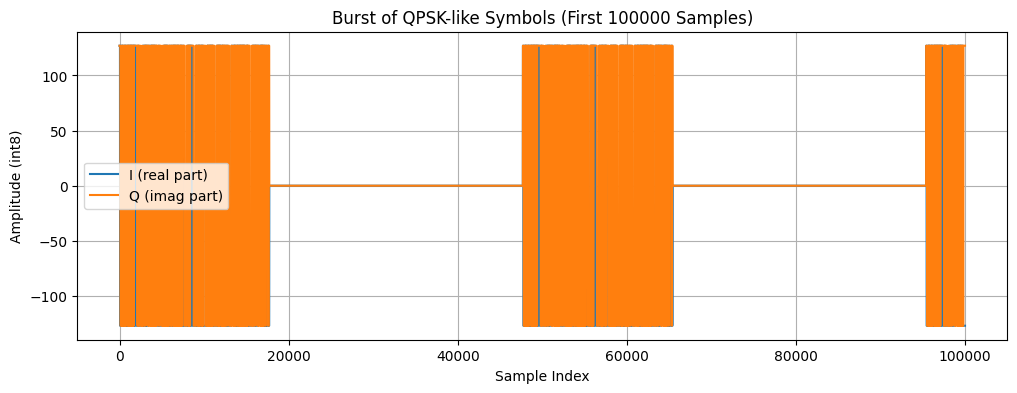

In [12]:
#plot first 1000 samples to verify pattern
import matplotlib.pyplot as plt
N = 100000   # number of samples to plot (adjust if needed)
plt.figure(figsize=(12,4))
plt.plot(I_full[:N], label="I (real part)")
plt.plot(Q_full[:N], label="Q (imag part)")
plt.title("Burst of QPSK-like Symbols (First {} Samples)".format(N))
plt.xlabel("Sample Index")
plt.ylabel("Amplitude (int8)")
plt.legend()
plt.grid(True)
plt.show()